# Induction Heating Public Demo

This result-saved notebook is the public view for induction-heating demos while BEM reference code is migrated into `src` and `validation_test`.

In [1]:
from pathlib import Path
import json
from IPython.display import Markdown, Image, display

CWD = Path.cwd()
if (CWD / 'public_demo_results.json').exists():
    NOTEBOOK_DIR = CWD
    REPO = NOTEBOOK_DIR.parents[1]
else:
    REPO = CWD
    NOTEBOOK_DIR = REPO / 'docs' / 'induction_heating'
demo = json.loads((NOTEBOOK_DIR / 'public_demo_results.json').read_text(encoding='utf-8'))
catalog = json.loads((NOTEBOOK_DIR / 'induction_heating_examples_catalog_results.json').read_text(encoding='utf-8'))
print(json.dumps(demo['summary'], ensure_ascii=False, indent=2))

{
  "selected_demo_count": 9,
  "selected_figure_count": 4,
  "catalog_script_count": 20,
  "catalog_artifact_count": 8,
  "protected_script_count": 20,
  "companion_status": "scattered_rhs_clean_test moved to validation_test; bem_reference still must split into src API + validation_test before examples rerouting; demoted_samples remain protected until replacements exist."
}


In [2]:
display(Markdown('## Public route\n\nInduction-heating examples are shown here as runnable companions while BEM/NGSBEM behavior is split into src API and validation_test. The full source ledger is [induction_heating_examples_catalog.ipynb](induction_heating_examples_catalog.ipynb), and the nonlinear ESIM benchmark notebook is [../ih_esim_benchmark/esim_showcase.ipynb](../ih_esim_benchmark/esim_showcase.ipynb).'))

## Public route

Induction-heating examples are shown here as runnable companions while BEM/NGSBEM behavior is split into src API and validation_test. The full source ledger is [induction_heating_examples_catalog.ipynb](induction_heating_examples_catalog.ipynb), and the nonlinear ESIM benchmark notebook is [../ih_esim_benchmark/esim_showcase.ipynb](../ih_esim_benchmark/esim_showcase.ipynb).

In [3]:
def table(headers, rows):
    return '\n'.join(['| ' + ' | '.join(headers) + ' |', '|' + '|'.join(['---'] * len(headers)) + '|'] + ['| ' + ' | '.join(str(c) for c in row) + ' |' for row in rows])

commands = {
    'examples/induction_heating/esim_demo.py': 'python examples/induction_heating/esim_demo.py',
    'examples/induction_heating/demo_esim_impedance.py': 'python examples/induction_heating/demo_esim_impedance.py',
    'examples/induction_heating/demo_wpt_coupling.py': 'python examples/induction_heating/demo_wpt_coupling.py',
    'examples/induction_heating/bem_reference/bem_inductance.py': 'python examples/induction_heating/bem_reference/bem_inductance.py',
    'validation_test/induction_heating/scattered_rhs_clean_test/clean_filament_test.py': 'python validation_test/induction_heating/scattered_rhs_clean_test/clean_filament_test.py',
}
rows = []
for r in demo['selected_records']:
    path = r['path']
    link = f'[`{path}`](../../{path})'
    art = r.get('sibling_artifacts', r.get('artifacts', []))
    artifact = '-' if not art else ', '.join(f'[{Path(a["path"]).name}](../../{a["path"]})' for a in art[:2])
    summary = r.get('source', {}).get('summary', '').replace('|', '/')[:140]
    rows.append([link, r['lane'], f'`{commands.get(path, "python " + path)}`', artifact, summary])
display(Markdown('## Selected runnable records\n\n' + table(['record', 'lane', 'command', 'artifact', 'summary'], rows)))

## Selected runnable records

| record | lane | command | artifact | summary |
|---|---|---|---|---|
| [`examples/induction_heating/esim_demo.py`](../../examples/induction_heating/esim_demo.py) | docs_tutorial_notebook_candidate | `python examples/induction_heating/esim_demo.py` | - | ESIM Induction Heating Demo This script demonstrates the ESIM (Effective Surface Impedance Method) for analyzing induction heating of a stee |
| [`examples/induction_heating/demo_esim_impedance.py`](../../examples/induction_heating/demo_esim_impedance.py) | docs_tutorial_notebook_candidate | `python examples/induction_heating/demo_esim_impedance.py` | - | ESIM Coupled Solver Demo: Coil-Workpiece Impedance Calculation This example demonstrates: 1. Complex permeability support (mu' - j*mu") 2. C |
| [`examples/induction_heating/esim_induction_heating_demo.py`](../../examples/induction_heating/esim_induction_heating_demo.py) | docs_tutorial_notebook_candidate | `python examples/induction_heating/esim_induction_heating_demo.py` | - | ESIM Induction Heating Coupled Solver Demo This script demonstrates the complete induction heating analysis workflow using: 1. Spiral coil m |
| [`examples/induction_heating/demo_wpt_coupling.py`](../../examples/induction_heating/demo_wpt_coupling.py) | docs_showcase_candidate | `python examples/induction_heating/demo_wpt_coupling.py` | - | WPT (Wireless Power Transfer) Coil Coupling Analysis Demo This example demonstrates: 1. Mutual inductance calculation using Neumann integral |
| [`examples/induction_heating/demo_rwg_efie_3d.py`](../../examples/induction_heating/demo_rwg_efie_3d.py) | research_docs_or_validation_review | `python examples/induction_heating/demo_rwg_efie_3d.py` | - | RWG-EFIE 3D Induction Heating Demo This example demonstrates the RWG-EFIE (Rao-Wilton-Glisson Electric Field Integral Equation) solver for i |
| [`examples/induction_heating/bem_reference/bem_inductance.py`](../../examples/induction_heating/bem_reference/bem_inductance.py) | src_api_or_validation_locked | `python examples/induction_heating/bem_reference/bem_inductance.py` | - | BEM inductance extraction via source/sink saddle point EFIE. Core solver for self-inductance extraction using ngsolve.bem LaplaceSL. Solves  |
| [`examples/induction_heating/bem_reference/ngsbem_coupled.py`](../../examples/induction_heating/bem_reference/ngsbem_coupled.py) | src_api_or_validation_locked | `python examples/induction_heating/bem_reference/ngsbem_coupled.py` | - | ngsbem_coupled.py Phase 3: Unified PEEC + Core Coupled Solver Combines: - Phase 1: ngsbem PEEC Loop-Star (conductor coil impedance) - Phase  |
| [`validation_test/induction_heating/scattered_rhs_clean_test/clean_filament_test.py`](../../validation_test/induction_heating/scattered_rhs_clean_test/clean_filament_test.py) | validation_test_candidate | `python validation_test/induction_heating/scattered_rhs_clean_test/clean_filament_test.py` | [clean_filament.vol](../../validation_test/induction_heating/scattered_rhs_clean_test/clean_filament.vol) | Clean test for scattered-field Robin RHS bug investigation. HISTORICAL (2026-04-24): the production scattered path (``calc_fem_kelvin.solve_ |
| [`examples/induction_heating/demoted_samples/ih_fem_kelvin_sample.py`](../../examples/induction_heating/demoted_samples/ih_fem_kelvin_sample.py) | protected_panel_sample_rework | `python examples/induction_heating/demoted_samples/ih_fem_kelvin_sample.py` | [ih_closed_torus.jou](../../examples/induction_heating/demoted_samples/ih_closed_torus.jou), [ih_fem_kelvin_sample.jou](../../examples/induction_heating/demoted_samples/ih_fem_kelvin_sample.jou) | FEM-Kelvin sample: gapped torus coil + cylindrical workpiece + air + Kelvin. Cubit Python script (playback from Cubit GUI or batch mode). Th |

## Saved ESIM benchmark figures

### `docs/ih_esim_benchmark/benchmark_plot.png`  
sha256 `0810120eb7d26cba`

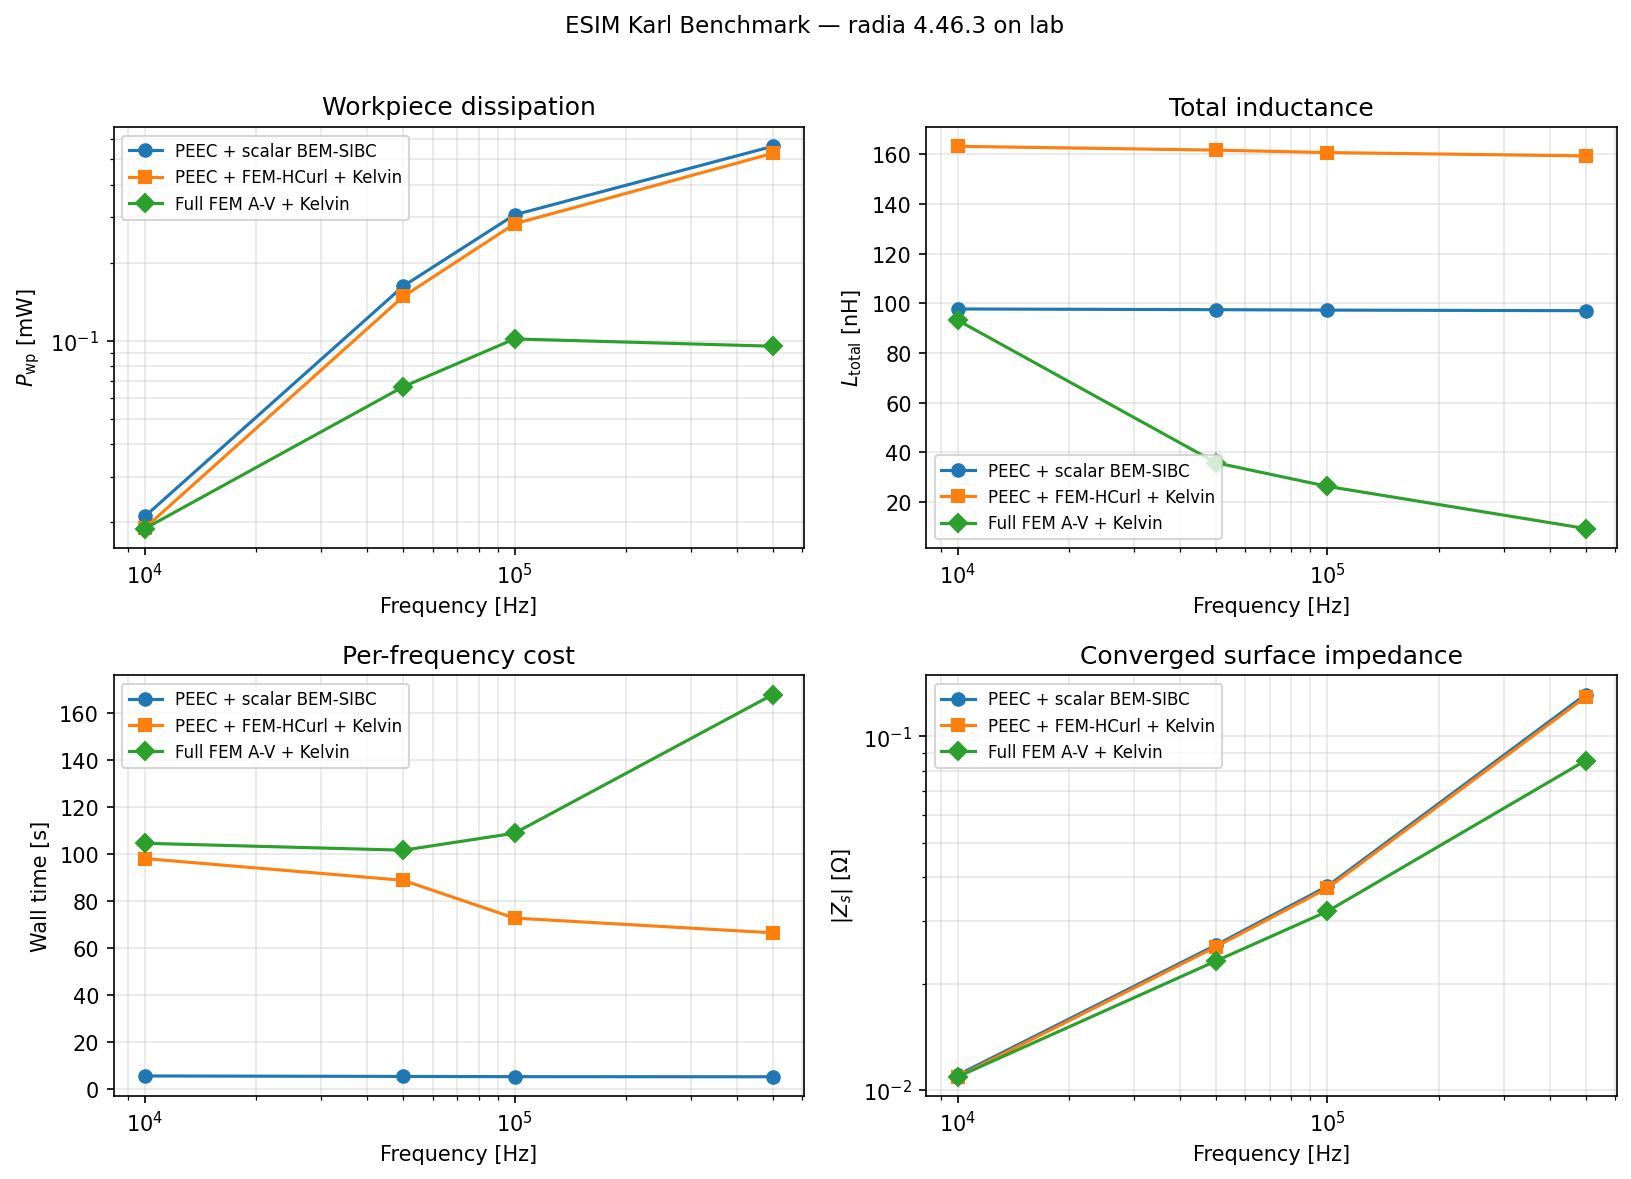

### `docs/ih_esim_benchmark/sweep_heatmap_digest.png`  
sha256 `26bc82ff32933f08`

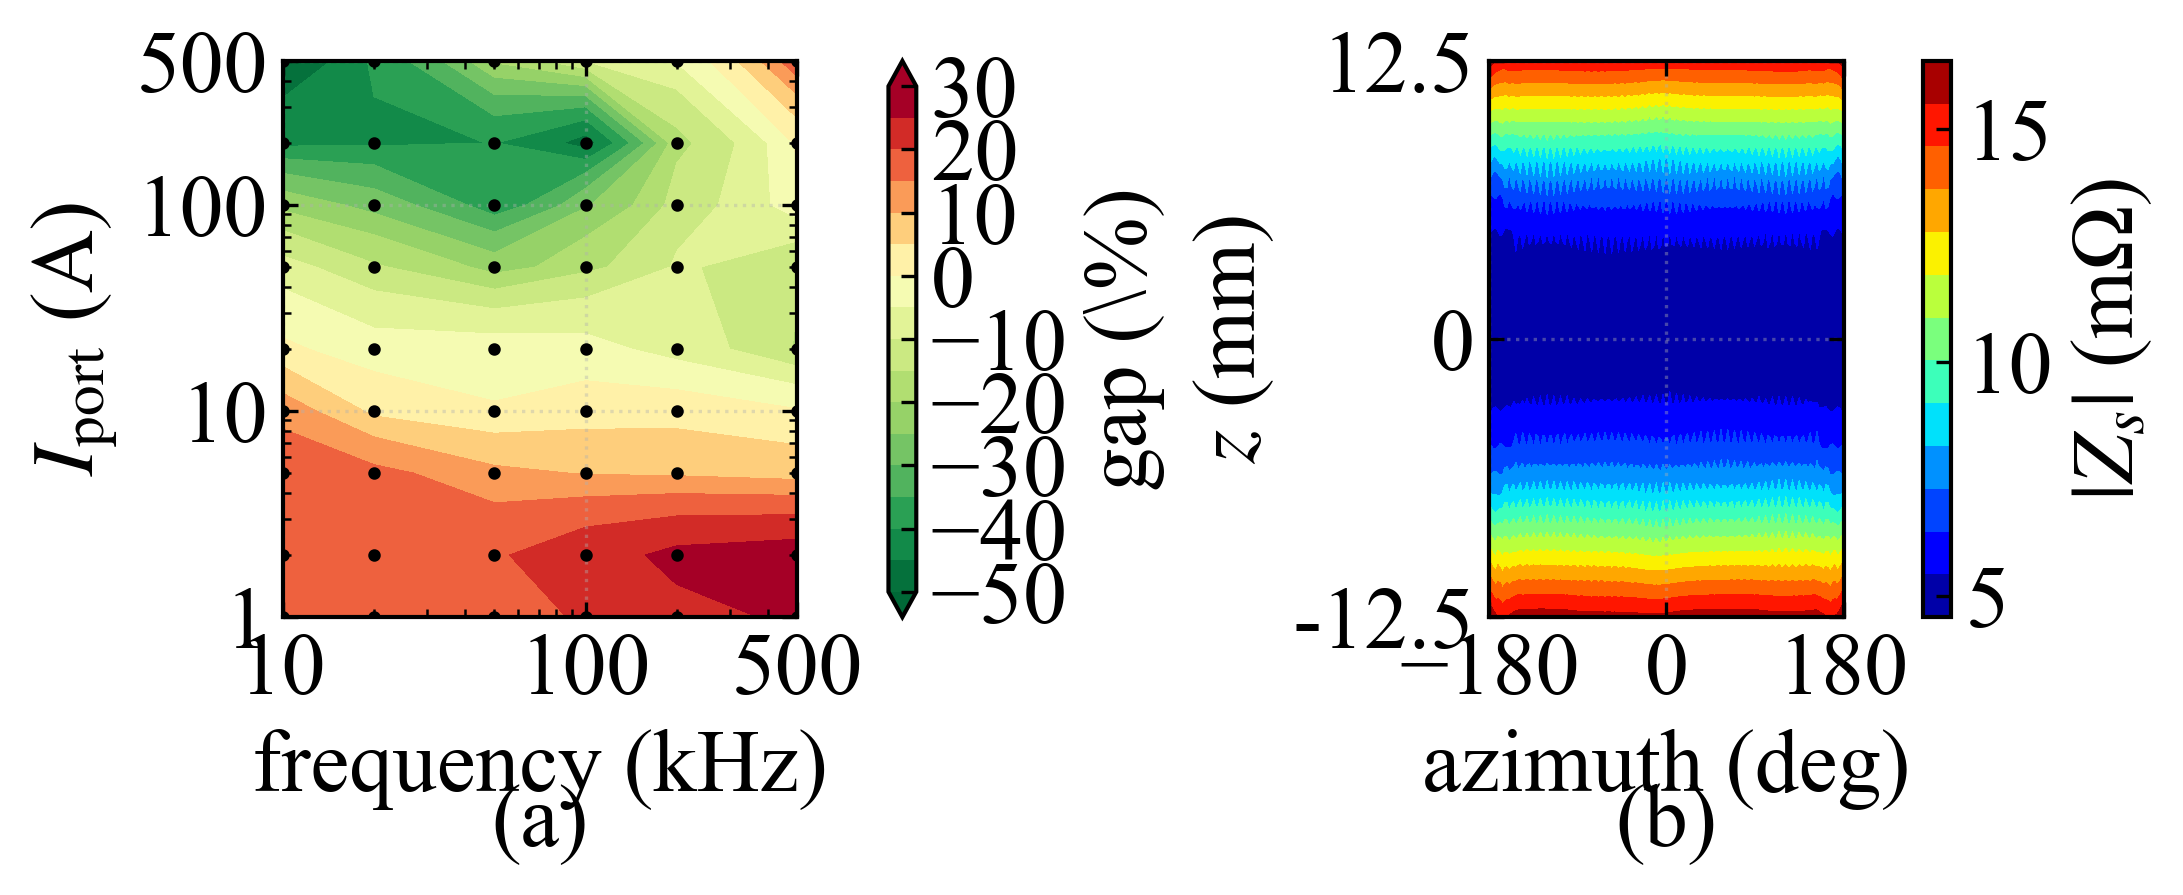

### `docs/ih_esim_benchmark/Zs_per_dof_map.png`  
sha256 `c0a701efa5030121`

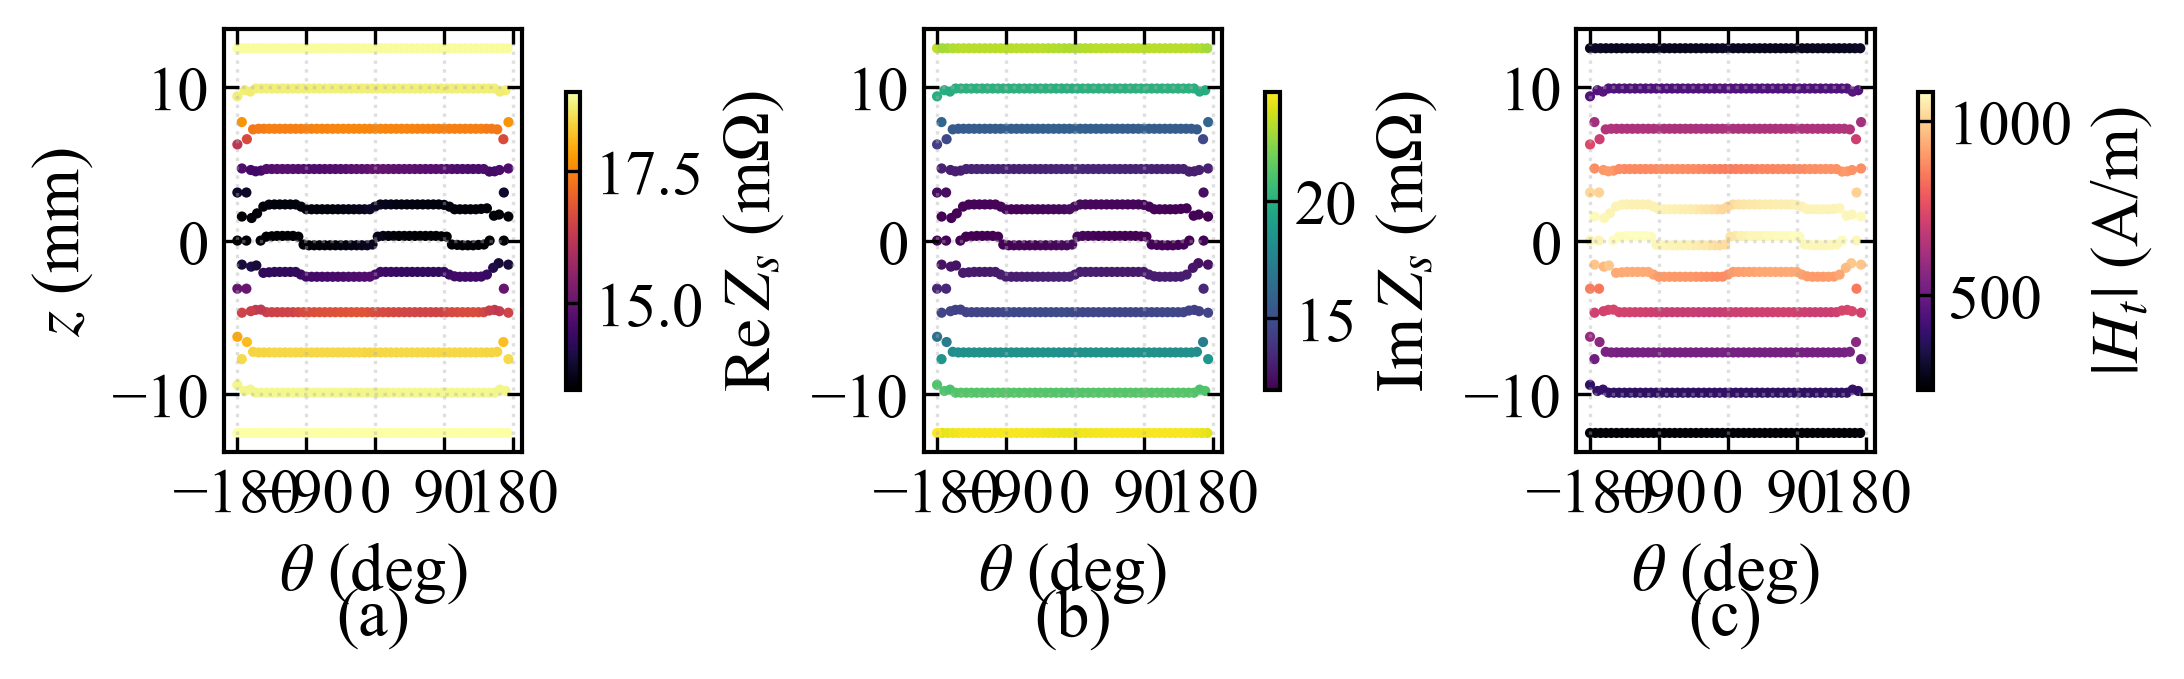

### `docs/ih_esim_benchmark/karl_history_per_panel_relax03.png`  
sha256 `99a29dfeba226836`

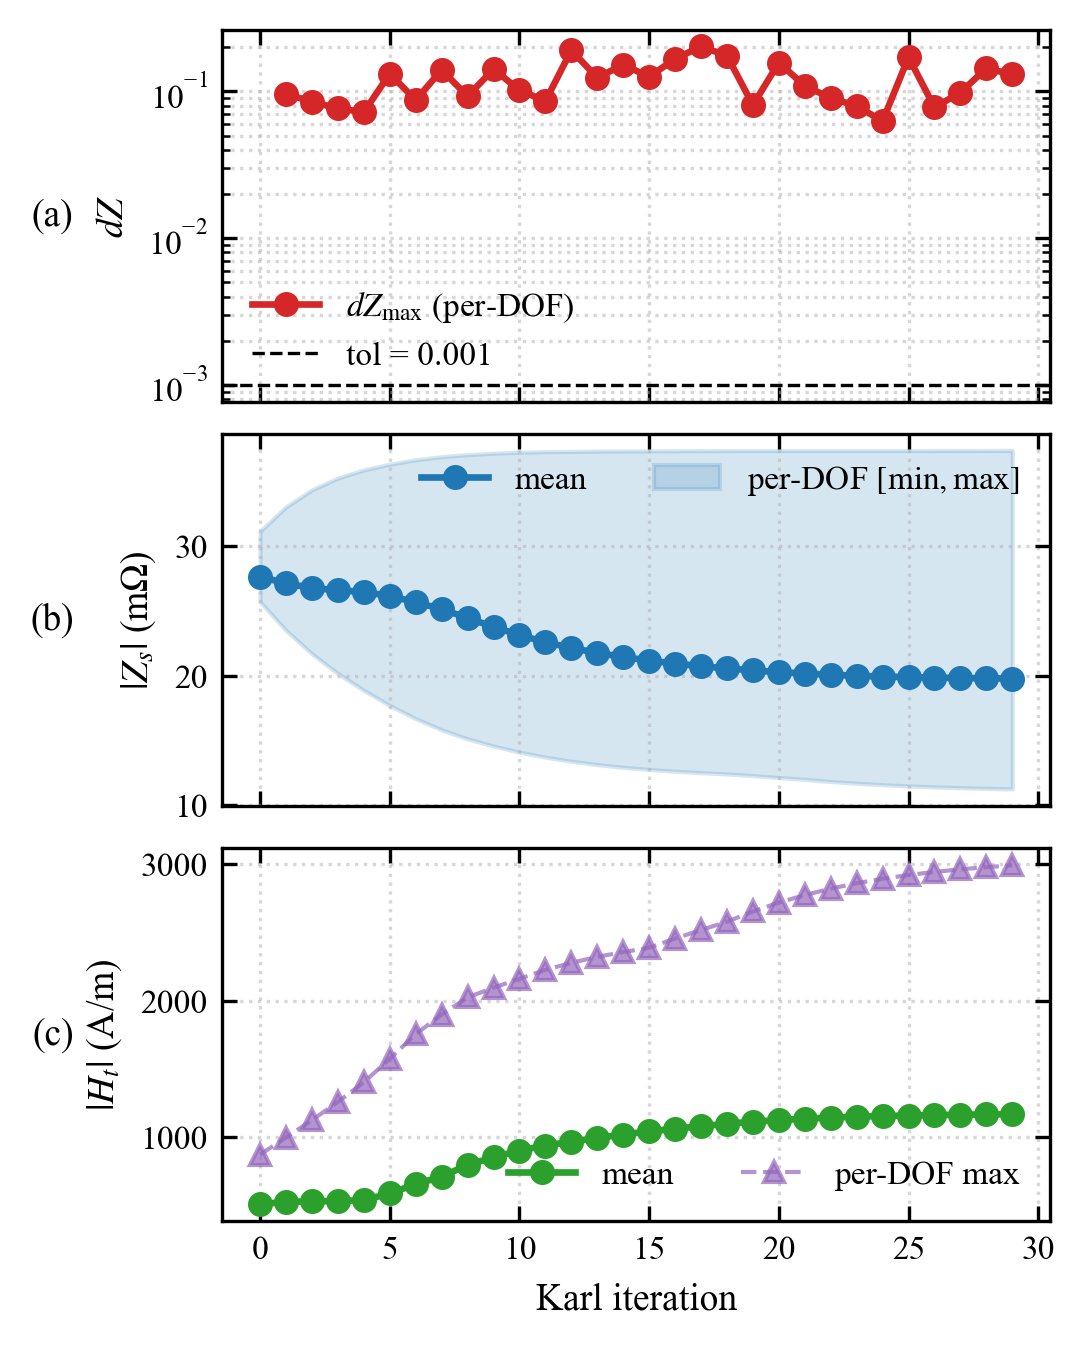

In [4]:
if demo['selected_figures']:
    display(Markdown('## Saved ESIM benchmark figures'))
for item in demo['selected_figures']:
    p = REPO / item['path']
    display(Markdown(f'### `{item["path"]}`  \nsha256 `{item["sha256"][:16]}`'))
    if p.exists():
        display(Image(filename=str(p), width=620))
    else:
        display(Markdown('Figure file is not present in this checkout.'))

In [5]:
protected = [r for r in catalog['records'] if r.get('protected_reference_count')]
rows = []
for r in protected[:18]:
    first = r['protected_references'][0] if r.get('protected_references') else {}
    where = f'{first.get("path", "")}:{first.get("line", "")}' if first else '-'
    rows.append([f'[`{r["path"]}`](../../{r["path"]})', r['protected_reference_count'], where, r['lane']])
display(Markdown('## Protected validation references\n\n' + table(['script', 'refs', 'first protected reference', 'lane'], rows)))

## Protected validation references

| script | refs | first protected reference | lane |
|---|---|---|---|
| [`examples/induction_heating/bem_reference/bem_coupled_solver.py`](../../examples/induction_heating/bem_reference/bem_coupled_solver.py) | 1 | src/radia.egg-info/SOURCES.txt:371 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/bem_inductance.py`](../../examples/induction_heating/bem_reference/bem_inductance.py) | 3 | validation_test/panels/test_ih_solvers.py:138 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/calc_heating_bem.py`](../../examples/induction_heating/bem_reference/calc_heating_bem.py) | 3 | src/radia.egg-info/SOURCES.txt:373 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/calc_inductance.py`](../../examples/induction_heating/bem_reference/calc_inductance.py) | 1 | src/radia.egg-info/SOURCES.txt:374 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/cubit_bem_extractor.py`](../../examples/induction_heating/bem_reference/cubit_bem_extractor.py) | 1 | src/radia.egg-info/SOURCES.txt:375 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/ngsbem_coupled.py`](../../examples/induction_heating/bem_reference/ngsbem_coupled.py) | 1 | src/radia.egg-info/SOURCES.txt:376 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/ngsbem_eddy.py`](../../examples/induction_heating/bem_reference/ngsbem_eddy.py) | 1 | src/radia.egg-info/SOURCES.txt:377 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/ngsbem_interface.py`](../../examples/induction_heating/bem_reference/ngsbem_interface.py) | 1 | src/radia.egg-info/SOURCES.txt:378 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/ngsbem_peec.py`](../../examples/induction_heating/bem_reference/ngsbem_peec.py) | 1 | src/radia.egg-info/SOURCES.txt:379 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/ngsbem_peec_body_coupling.py`](../../examples/induction_heating/bem_reference/ngsbem_peec_body_coupling.py) | 1 | src/radia.egg-info/SOURCES.txt:380 | src_api_or_validation_locked |
| [`examples/induction_heating/bem_reference/sweep_bem_coupled_maxh.py`](../../examples/induction_heating/bem_reference/sweep_bem_coupled_maxh.py) | 1 | src/radia.egg-info/SOURCES.txt:381 | src_api_or_validation_locked |
| [`examples/induction_heating/demo_esim_impedance.py`](../../examples/induction_heating/demo_esim_impedance.py) | 1 | src/radia.egg-info/SOURCES.txt:366 | docs_tutorial_notebook_candidate |
| [`examples/induction_heating/demo_rwg_efie_3d.py`](../../examples/induction_heating/demo_rwg_efie_3d.py) | 1 | src/radia.egg-info/SOURCES.txt:367 | research_docs_or_validation_review |
| [`examples/induction_heating/demo_wpt_coupling.py`](../../examples/induction_heating/demo_wpt_coupling.py) | 1 | src/radia.egg-info/SOURCES.txt:368 | docs_showcase_candidate |
| [`examples/induction_heating/demoted_samples/ih_closed_torus.py`](../../examples/induction_heating/demoted_samples/ih_closed_torus.py) | 1 | src/radia.egg-info/SOURCES.txt:383 | protected_panel_sample_rework |
| [`examples/induction_heating/demoted_samples/ih_fem_kelvin_sample.py`](../../examples/induction_heating/demoted_samples/ih_fem_kelvin_sample.py) | 1 | src/radia.egg-info/SOURCES.txt:384 | protected_panel_sample_rework |
| [`examples/induction_heating/demoted_samples/ih_fem_kelvin_skin.py`](../../examples/induction_heating/demoted_samples/ih_fem_kelvin_skin.py) | 1 | src/radia.egg-info/SOURCES.txt:385 | protected_panel_sample_rework |
| [`examples/induction_heating/esim_demo.py`](../../examples/induction_heating/esim_demo.py) | 2 | docs/esim/EXAMPLES.md:21 | docs_tutorial_notebook_candidate |

In [6]:
for r in demo['selected_records'][:3]:
    excerpt = r['source']['text'][:1100].replace('```', '` ` `')
    display(Markdown(f'## Source excerpt: `{r["path"]}`\n\n```python\n{excerpt}\n```'))

## Source excerpt: `examples/induction_heating/esim_demo.py`

```python
"""
ESIM Induction Heating Demo

This script demonstrates the ESIM (Effective Surface Impedance Method) for
analyzing induction heating of a steel workpiece with nonlinear magnetic material.

The demo:
1. Creates an ESI table from a steel BH-curve
2. Sets up a block workpiece with ESIM
3. Simulates a simple field distribution and computes power losses
4. Compares linear vs nonlinear impedance behavior

Reference:
    K. Hollaus, M. Kaltenbacher, J. Schoberl, "A Nonlinear Effective Surface
    Impedance in a Magnetic Scalar Potential Formulation," IEEE Trans. Magnetics,
    2025, DOI: 10.1109/TMAG.2025.3613932

Author: Radia Development Team
Date: 2026-01-08
"""

import sys
import os
import numpy as np

# Add radia module path
sys.path.insert(0, os.path.join(os.path.dirname(__file__), '../../src/radia'))

from esim_cell_problem import (
    ESIMCellProblemSolver,
    BHCurveInterpolator,
    generate_esi_table_from_bh_curve
)
from esim_workpiece import create_esim_block, create_esim_cylinder


def print_header(title):
    """Print a formatted heade
```

## Source excerpt: `examples/induction_heating/demo_esim_impedance.py`

```python
"""
ESIM Coupled Solver Demo: Coil-Workpiece Impedance Calculation

This example demonstrates:
1. Complex permeability support (mu' - j*mu")
2. Coil-workpiece coupled impedance calculation
3. Efficiency and power analysis for induction heating

Author: Radia Development Team
Date: 2026-01-08
"""

import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(__file__), '../../src'))

import numpy as np

# Import ESIM modules from radia package
from radia import (
    ESIMCellProblemSolver,
    BHCurveInterpolator,
    ComplexPermeabilityInterpolator,
    InductionHeatingCoil,
    ESIMCoupledSolver,
    create_esim_block,
    create_esim_cylinder,
)
import radia as rad


def demo_complex_permeability():
    """Demonstrate complex permeability support."""
    print("=" * 60)
    print("Demo 1: Complex Permeability (mu' - j*mu\")")
    print("=" * 60)
    print()

    # Ferrite material with complex permeability
    # mu'_r = 1000 (energy storage), mu"_r = 100 (loss)
    # Loss tangent = mu"/mu' = 0.1

    mu_prime_r = 1000
    mu_double_
```

## Source excerpt: `examples/induction_heating/esim_induction_heating_demo.py`

```python
"""
ESIM Induction Heating Coupled Solver Demo

This script demonstrates the complete induction heating analysis workflow using:
1. Spiral coil model (FastImp or analytical)
2. ESIM workpiece with nonlinear ferromagnetic material
3. Fixed-point coupled solver

The demo simulates a typical induction heating setup for surface hardening
of a steel billet.

Reference:
    K. Hollaus, M. Kaltenbacher, J. Schoberl, "A Nonlinear Effective Surface
    Impedance in a Magnetic Scalar Potential Formulation," IEEE Trans. Magnetics,
    2025, DOI: 10.1109/TMAG.2025.3613932

Author: Radia Development Team
Date: 2026-01-08
"""

import sys
import os
import numpy as np

# Add radia module path
sys.path.insert(0, os.path.join(os.path.dirname(__file__), '../../src/radia'))

from esim_coupled_solver import (
    InductionHeatingCoil,
    ESIMCoupledSolver,
    solve_induction_heating
)
from esim_workpiece import create_esim_block, create_esim_cylinder


def print_header(title):
    """Print a formatted header."""
    print()
    print("=" * 70)
    print(title)
  
```

In [7]:
assert demo['summary']['selected_demo_count'] == len(demo['selected_records'])
assert catalog['summary']['script_count'] == demo['summary']['catalog_script_count']
print('induction_heating public demo synchronized')

induction_heating public demo synchronized
